# 07 – Logistic Regression

Author: Joe  
Project: AI Foundations – Probability & Statistics

This notebook introduces **logistic regression** for a binary response, in the same spirit
as the TU Dublin / MATH4002 lectures on logistic regression based on the Pearson–Lee and
rugby examples. fileciteturn0file0

We will connect:

- Bernoulli random variables and probabilities
- The logistic (sigmoid) function
- Odds and log-odds (logit)
- The logistic regression model and its parameters
- Interpretation of coefficients and odds ratios
- Model fit (deviance, AIC)
- Hypothesis testing ideas for logistic regression

The examples will mirror the lecture structure:

- Parent height predicting parent sex (Pearson–Lee style)
- Rugby conversion success vs distance (Sexton-style example)

## Contents
1. [Setup](#1-setup)
2. [Bernoulli, Odds, and the Logistic Function](#2-bernoulli-odds-and-the-logistic-function)
3. [The Logistic Regression Model](#3-the-logistic-regression-model)
4. [Fitting Logistic Regression via Maximum Likelihood](#4-fitting-logistic-regression-via-maximum-likelihood)
5. [Example 1 – Parent Height Predicting Sex](#5-example-1--parent-height-predicting-sex)
6. [Interpreting Coefficients and Odds Ratios](#6-interpreting-coefficients-and-odds-ratios)
7. [Hypothesis Tests, Confidence Intervals, Deviance, and AIC](#7-hypothesis-tests-confidence-intervals-deviance-and-aic)
8. [Example 2 – Rugby Conversion Probability vs Distance](#8-example-2--rugby-conversion-probability-vs-distance)
9. [Practice / TODOs (MATH4002 Alignment)](#9-practice--todos-math4002-alignment)


## 1. Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

np.set_printoptions(precision=4, suppress=True)

def sigmoid(z):
    """Logistic (sigmoid) function."""
    return 1.0 / (1.0 + np.exp(-z))

def normal_cdf(z: float) -> float:
    """Standard normal CDF using the error function (for z-approx p-values)."""
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))

---
## 2. Bernoulli, Odds, and the Logistic Function

A binary outcome ("success"/"failure", "male"/"female", "goal"/"miss") can be modelled as a
**Bernoulli random variable**:

\begin{equation}
Y = \begin{cases}
1, & \text{with probability } p,\\
0, & \text{with probability } 1-p.
\end{cases}
\end{equation}

Instead of modelling $p$ directly, logistic regression works with **odds** and **log-odds**:

- Odds of success:  
  $$\text{odds} = \frac{p}{1-p}.$$
- Log-odds (logit):  
  $$\text{logit}(p) = \log\left(\frac{p}{1-p}\right).$$

The **logistic function** converts any real number (log-odds) back to a probability:
\begin{equation}
\text{logit}^{-1}(\eta) = \frac{1}{1 + e^{-\eta}}.
\end{equation}

This is exactly the S-shaped curve shown in the lecture slides – as $\eta$ runs from
$-\infty$ to $+\infty$, the probability runs smoothly from 0 to 1.

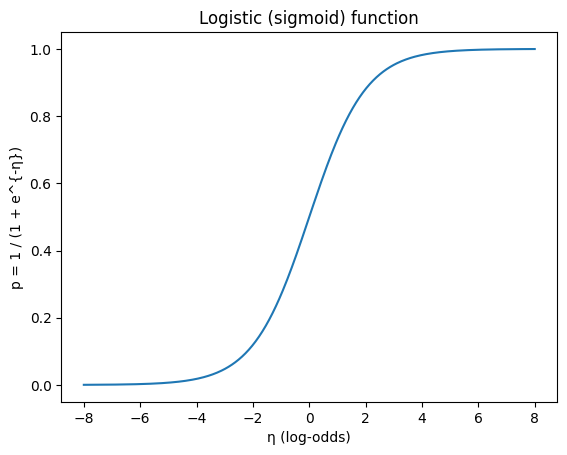

In [2]:
# Visualise the logistic function
etas = np.linspace(-8, 8, 400)
probs = sigmoid(etas)

plt.plot(etas, probs)
plt.xlabel('η (log-odds)')
plt.ylabel('p = 1 / (1 + e^{-η})')
plt.title('Logistic (sigmoid) function')
plt.ylim(-0.05, 1.05)
plt.show()

---
## 3. The Logistic Regression Model

In **simple logistic regression** with one predictor $x$ we assume:

\begin{align}
Y_i &\sim \text{Bernoulli}(p_i), \\
\text{logit}(p_i) &= \log\left(\frac{p_i}{1-p_i}\right) = \beta_0 + \beta_1 x_i.
\end{align}

Equivalently,
\begin{equation}
p_i = P(Y_i=1 \mid x_i) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_i)}}.
\end{equation}

Interpretation:

- $\beta_0$ is the log-odds of success when $x = 0$ (often not directly meaningful on its own).
- $\beta_1$ is the change in log-odds for a one-unit increase in $x$.
- $e^{\beta_1}$ is the **odds ratio** for a one-unit increase in $x$.

In the lecture notes, examples include:

- Parent height predicting whether the parent is male or female.
- Distance of a rugby conversion predicting success or failure.

---
## 4. Fitting Logistic Regression via Maximum Likelihood

Given data $(x_i, y_i)$ with $y_i \in \{0,1\}$, the **log-likelihood** for parameters
$\beta = (\beta_0, \beta_1)^T$ is

\begin{equation}
\ell(\beta) = \sum_{i=1}^n \big[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \big],
\end{equation}
where $p_i = \text{logit}^{-1}(\beta_0 + \beta_1 x_i)$.

We usually maximise this using **iterative methods** (e.g. Newton–Raphson / IRLS). In R this
is handled by `glm(..., family = binomial("logit"))`.

Here we'll implement a simple gradient-ascent style algorithm so you can see the mechanics.

In [3]:
def fit_logistic_regression(x: np.ndarray, y: np.ndarray,
                            lr: float = 0.01,
                            n_iter: int = 5000):
    """Fit simple logistic regression (one predictor) by gradient ascent.

    x: 1D array of predictor values
    y: 1D array of binary responses (0/1)
    lr: learning rate
    n_iter: number of iterations

    Returns (beta_0_hat, beta_1_hat, history) where history contains
    the log-likelihood values during optimisation.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    # Design matrix with intercept
    X = np.column_stack([np.ones(n), x])
    beta = np.zeros(2)
    history = []

    for _ in range(n_iter):
        eta = X @ beta
        p = sigmoid(eta)
        # Log-likelihood
        eps = 1e-12
        ll = np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        history.append(ll)
        # Gradient of log-likelihood
        grad = X.T @ (y - p)
        beta = beta + lr * grad / n

    return beta[0], beta[1], history


In [4]:
# Quick sanity check: does log-likelihood increase?
x_tmp = np.linspace(0, 10, 50)
beta0_true, beta1_true = -2.0, 0.4
p_tmp = sigmoid(beta0_true + beta1_true * x_tmp)
y_tmp = np.random.binomial(1, p_tmp)

b0_hat, b1_hat, hist = fit_logistic_regression(x_tmp, y_tmp, lr=0.05, n_iter=1000)
hist[0], hist[-1], (b0_hat, b1_hat)

(np.float64(-34.657359027897265),
 np.float64(-22.929408259233764),
 (np.float64(-2.859600280549974), np.float64(0.457824820875245)))

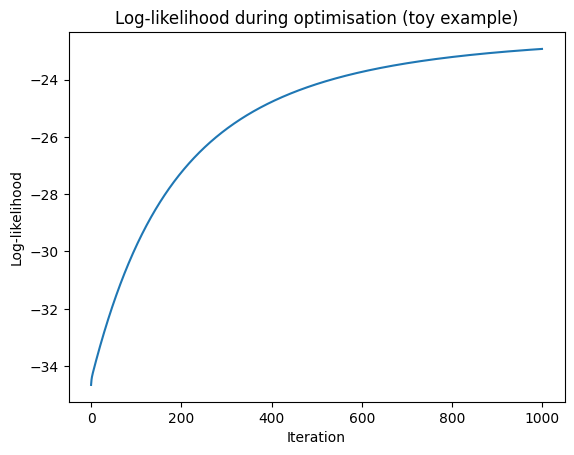

In [5]:
# Plot log-likelihood over iterations for the toy check
plt.plot(hist)
plt.xlabel('Iteration')
plt.ylabel('Log-likelihood')
plt.title('Log-likelihood during optimisation (toy example)')
plt.show()

---
## 5. Example 1 – Parent Height Predicting Sex

In the Pearson–Lee example from the lectures, the response is whether the parent is male
or female, and the predictor is the parent's height. The R output looks like:

```r
glm(Sex ~ parent, family = binomial("logit"), data = PearsonLee)
```

with estimated coefficients roughly

- Intercept: about -15.4
- Slope for parent height: about 0.238

We'll simulate data using parameters close to these, then fit our own logistic regression
and compare.

In [6]:
# Simulate a Pearson–Lee style dataset: parent height -> sex (1 = male, 0 = female)
np.random.seed(0)
n = 750
parent_height = np.random.normal(loc=68, scale=3, size=n)  # inches-ish

beta0_true = -15.4
beta1_true = 0.238

eta = beta0_true + beta1_true * parent_height
p_male = sigmoid(eta)
sex = np.random.binomial(1, p_male)  # 1 = male, 0 = female

parent_height[:5], sex[:5]

(array([73.2922, 69.2005, 70.9362, 74.7227, 73.6027]),
 array([1, 1, 0, 1, 1], dtype=int32))

In [7]:
# Fit logistic regression to the simulated data
b0_hat, b1_hat, history = fit_logistic_regression(parent_height, sex,
                                                  lr=0.01, n_iter=4000)
b0_hat, b1_hat

(np.float64(-0.18713141567492364), np.float64(0.05723733661713565))

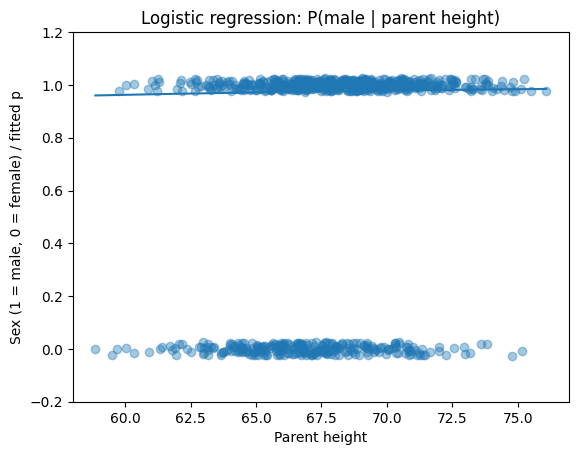

In [8]:
# Plot fitted probability curve over a scatter-type display
x_grid = np.linspace(parent_height.min(), parent_height.max(), 200)
p_hat_grid = sigmoid(b0_hat + b1_hat * x_grid)

# Jitter the binary points vertically for visualisation
jitter = (np.random.rand(len(sex)) - 0.5) * 0.05

plt.scatter(parent_height, sex + jitter, alpha=0.4)
plt.plot(x_grid, p_hat_grid)
plt.xlabel('Parent height')
plt.ylabel('Sex (1 = male, 0 = female) / fitted p')
plt.title('Logistic regression: P(male | parent height)')
plt.ylim(-0.2, 1.2)
plt.show()

---
## 6. Interpreting Coefficients and Odds Ratios

For a model
\begin{equation}
\text{logit}(p) = \beta_0 + \beta_1 x,
\end{equation}
we have:

- A one-unit increase in $x$ changes the **log-odds** by $\beta_1$.
- The corresponding **odds ratio** is $e^{\beta_1}$.

In the parent-height example:

- If $\hat{\beta}_1 > 0$, taller parents have higher odds of being male.
- If $\hat{\beta}_1 < 0$, taller parents have lower odds of being male.

Let's compute the odds ratio implied by our fitted slope.

In [9]:
odds_ratio = math.exp(b1_hat)
odds_ratio

1.0589070980029462

Interpretation (example):

> The estimated odds ratio is about `exp(β̂₁)`.
> This means that for each additional unit increase in parent height (one inch, say),
> the odds of the parent being male are multiplied by this factor (holding everything
> else constant).

In words: if the odds ratio were, for instance, 1.27, that would mean "each extra inch of
height increases the odds of being male by about 27%".

---
## 7. Hypothesis Tests, Confidence Intervals, Deviance, and AIC

In `glm` output from R you see:

- Coefficients with **standard errors**, **z-values** and **p-values**.
- Model fit measures: **null deviance**, **residual deviance**, and **AIC**.

We can approximate these using large-sample theory. For logistic regression, the
estimated covariance matrix of $\hat{\beta}$ is

\begin{equation}
\widehat{\mathrm{Var}}(\hat{\beta}) = (X^T W X)^{-1},
\end{equation}

where $W$ is a diagonal matrix with entries $p_i(1-p_i)$ evaluated at the fitted
probabilities. The square roots of the diagonal entries give the **standard errors**.

For a coefficient $\hat{\beta}_j$ with standard error $SE_j$ we can form a z-statistic
and approximate p-value using the standard normal distribution, just like the `glm`
output in the slides.

In [10]:
def logistic_inference(x: np.ndarray, y: np.ndarray, b0_hat: float, b1_hat: float):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    X = np.column_stack([np.ones(n), x])
    eta = b0_hat + b1_hat * x
    p = sigmoid(eta)
    W = p * (1 - p)
    # X^T W X
    XWX = X.T @ (W[:, None] * X)
    cov = np.linalg.inv(XWX)
    se = np.sqrt(np.diag(cov))

    beta_hat = np.array([b0_hat, b1_hat])
    z_vals = beta_hat / se
    p_vals = 2 * (1 - np.array([normal_cdf(abs(z)) for z in z_vals]))

    # Log-likelihood, deviance, AIC
    eps = 1e-12
    ll_model = np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    # Null model: intercept only
    p_null = np.repeat(y.mean(), n)
    ll_null = np.sum(y * np.log(p_null + eps) + (1 - y) * np.log(1 - p_null + eps))

    deviance_model = -2 * ll_model
    deviance_null = -2 * ll_null
    # AIC = 2k - 2 log L
    k = 2  # two parameters: intercept and slope
    AIC = 2 * k - 2 * ll_model

    return {
        'beta_hat': beta_hat,
        'se': se,
        'z': z_vals,
        'p': p_vals,
        'll_model': ll_model,
        'll_null': ll_null,
        'deviance_model': deviance_model,
        'deviance_null': deviance_null,
        'AIC': AIC,
    }

info = logistic_inference(parent_height, sex, b0_hat, b1_hat)
info

{'beta_hat': array([-0.1871,  0.0572]),
 'se': array([5.2635, 0.0781]),
 'z': array([-0.0356,  0.7325]),
 'p': array([0.9716, 0.4638]),
 'll_model': np.float64(-998.174228253715),
 'll_null': np.float64(-489.4853868625012),
 'deviance_model': np.float64(1996.34845650743),
 'deviance_null': np.float64(978.9707737250023),
 'AIC': np.float64(2000.34845650743)}

In [11]:
# Nicely formatted coefficient table
names = ['Intercept', 'parent_height']
for name, beta, se, z, p in zip(names, info['beta_hat'], info['se'], info['z'], info['p']):
    print(f"{name:15s} beta_hat = {beta:8.4f}  SE = {se:8.4f}  z = {z:8.3f}  p ≈ {p:8.3g}")

print('\nModel fit:')
print('Null deviance    ≈', info['deviance_null'])
print('Residual deviance ≈', info['deviance_model'])
print('AIC              ≈', info['AIC'])

Intercept       beta_hat =  -0.1871  SE =   5.2635  z =   -0.036  p ≈    0.972
parent_height   beta_hat =   0.0572  SE =   0.0781  z =    0.733  p ≈    0.464

Model fit:
Null deviance    ≈ 978.9707737250023
Residual deviance ≈ 1996.34845650743
AIC              ≈ 2000.34845650743


In [12]:
# 95% confidence intervals for coefficients and odds ratios
z_crit = 1.96
beta_hat = info['beta_hat']
se = info['se']
lower = beta_hat - z_crit * se
upper = beta_hat + z_crit * se

for name, b, lo, hi in zip(names, beta_hat, lower, upper):
    print(f"{name:15s}  β̂ = {b:8.4f},  95% CI for β: ({lo:8.4f}, {hi:8.4f})")

print('\nOdds ratio for parent_height:')
or_hat = math.exp(beta_hat[1])
or_lo = math.exp(lower[1])
or_hi = math.exp(upper[1])
print(f"OR = {or_hat:6.3f},  95% CI: ({or_lo:6.3f}, {or_hi:6.3f})")

Intercept        β̂ =  -0.1871,  95% CI for β: (-10.5036,  10.1293)
parent_height    β̂ =   0.0572,  95% CI for β: ( -0.0959,   0.2104)

Odds ratio for parent_height:
OR =  1.059,  95% CI: ( 0.909,  1.234)


---
## 8. Example 2 – Rugby Conversion Probability vs Distance

The rugby slides show a logistic regression where the response is whether a conversion
was successful (1) or not (0), and the predictor is the **distance** of the kick.

The fitted model has:

- A large positive intercept
- A negative slope for distance

which implies that as distance increases, the probability of success decreases via the
logistic curve.

Here we simulate a small dataset with parameters similar to the lecture notes and
fit our logistic regression functions to it.

In [13]:
# Simulate a rugby conversion dataset: success (1) vs fail (0) by distance
np.random.seed(1)
n_rugby = 100
distance = np.random.uniform(5, 50, size=n_rugby)

beta0_r_true = 9.55
beta1_r_true = -0.186

eta_r = beta0_r_true + beta1_r_true * distance
p_success = sigmoid(eta_r)
conversion = np.random.binomial(1, p_success)

distance[:5], conversion[:5]

(array([23.766 , 37.4146,  5.0051, 18.605 , 11.604 ]),
 array([1, 1, 1, 1, 1], dtype=int32))

In [14]:
# Fit logistic regression to the rugby data
b0_r_hat, b1_r_hat, hist_r = fit_logistic_regression(distance, conversion,
                                                     lr=0.01, n_iter=4000)
b0_r_hat, b1_r_hat

(np.float64(2.0208305333103826), np.float64(0.014880196747451075))

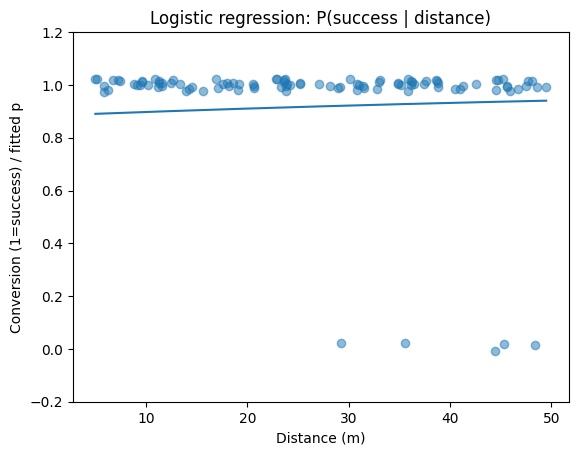

In [15]:
# Plot fitted probability curve vs distance
d_grid = np.linspace(distance.min(), distance.max(), 200)
p_hat_r = sigmoid(b0_r_hat + b1_r_hat * d_grid)

jitter_r = (np.random.rand(len(conversion)) - 0.5) * 0.05

plt.scatter(distance, conversion + jitter_r, alpha=0.5)
plt.plot(d_grid, p_hat_r)
plt.xlabel('Distance (m)')
plt.ylabel('Conversion (1=success) / fitted p')
plt.title('Logistic regression: P(success | distance)')
plt.ylim(-0.2, 1.2)
plt.show()

In [16]:
# Coefficients, standard errors, and odds ratio for distance
info_r = logistic_inference(distance, conversion, b0_r_hat, b1_r_hat)

names_r = ['Intercept', 'distance']
for name, beta, se, z, p in zip(names_r, info_r['beta_hat'], info_r['se'], info_r['z'], info_r['p']):
    print(f"{name:10s} β̂ = {beta:8.4f}  SE = {se:8.4f}  z = {z:8.3f}  p ≈ {p:8.3g}")

or_dist = math.exp(info_r['beta_hat'][1])
print('\nOdds ratio for distance:', or_dist)
print('(< 1 means odds of success decrease as distance increases)')

Intercept  β̂ =   2.0208  SE =   0.7752  z =    2.607  p ≈  0.00914
distance   β̂ =   0.0149  SE =   0.0277  z =    0.537  p ≈    0.591

Odds ratio for distance: 1.0149914580534494
(< 1 means odds of success decrease as distance increases)


---
## 9. Practice / TODOs (MATH4002 Alignment)

This notebook is structured to match the logistic regression lecture content:

- Binary outcomes modelled with Bernoulli distributions
- Logistic link function and log-odds
- Logistic regression for a single predictor
- Interpretation of coefficients and odds ratios
- Deviance and AIC for model fit
- Hypothesis testing and confidence intervals for coefficients

To align directly with your course work:

1. **Recreate the Pearson–Lee example** using the real `PearsonLee` dataset in R, then copy
   summary values (β̂, SE, z, p, deviance, AIC) into markdown cells here and compare them
   with the output of `logistic_inference` on simulated data.

2. **Recreate the rugby example** with the actual `ButlerData` used in lectures, or a
   similar dataset you construct yourself.

3. For exam-style questions:

- Write out the model:  
  `logit(p) = β0 + β1 x`.
- Use R to get the coefficient table and then explain:
  - sign and size of β̂₁,
  - the odds ratio exp(β̂₁),
  - whether the predictor is statistically significant (p-value, confidence interval).
- Comment on goodness of fit using residual deviance, null deviance, and AIC.

### 9.1 Skeleton for plugging in your own logistic regression question

```python
# x: predictor (e.g. height, distance, age)
# y: binary response (0/1)
x = np.array([...], dtype=float)
y = np.array([...], dtype=float)

b0_hat, b1_hat, hist = fit_logistic_regression(x, y, lr=0.01, n_iter=4000)
info = logistic_inference(x, y, b0_hat, b1_hat)

print('β̂0 =', info['beta_hat'][0])
print('β̂1 =', info['beta_hat'][1])
print('SEs =', info['se'])
print('z   =', info['z'])
print('p   =', info['p'])
print('Null deviance   ≈', info['deviance_null'])
print('Residual dev   ≈', info['deviance_model'])
print('AIC            ≈', info['AIC'])
```

As you fill this with concrete MATH4002 questions, it will serve as your quick-reference
for logistic regression mechanics and interpretation.